# Imports

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow_addons.layers import GroupNormalization
from scipy.linalg import sqrtm

# Load Metadata and Configuration

In [ ]:
USE_128 = True
IMG_CHANNELS = 3
BATCH_SIZE = 64
NOISE_DIM = 100
EPOCHS = 2

if USE_128:
    base_path = 'sampled/128_pix'
    df = pd.read_csv(f'{base_path}/128train_df.csv')
    IMG_SIZE = 128
else:
    base_path = 'sampled/64_pix'
    df = pd.read_csv(f'{base_path}/64train_df.csv')
    IMG_SIZE = 64

img_dir = os.path.join(base_path, f'split_photos_{IMG_SIZE}/train')
df['image_path'] = df.apply(lambda row: f"{img_dir}/{row['label']}/{row['photo_id']}.jpg", axis=1)
label_encoder = LabelEncoder()
df['label_idx'] = label_encoder.fit_transform(df['label'])
num_classes = len(label_encoder.classes_)
df = df.groupby('label').apply(lambda x: x.sample(n=1000, random_state=42)).reset_index(drop=True)


C:\Users\amrut\AppData\Local\Temp\ipykernel_1992\3683327313.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label').apply(lambda x: x.sample(n=1000, random_state=42)).reset_index(drop=True)


# Data Loader

In [3]:
def load_image(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img = np.asarray(img) / 127.5 - 1.0
    return img

def data_generator(df, batch_size):
    while True:
        df = df.sample(frac=1).reset_index(drop=True)
        for i in range(0, len(df), batch_size):
            batch = df.iloc[i:i+batch_size]
            images = np.array([load_image(p) for p in batch['image_path']])
            labels = tf.keras.utils.to_categorical(batch['label_idx'], num_classes)
            yield images, labels


# Iteration 1

## Conditional Generator

In [4]:
def build_generator():
    label_input = layers.Input(shape=(num_classes,))
    noise_input = layers.Input(shape=(NOISE_DIM,))
    x = layers.Concatenate()([noise_input, label_input])
    x = layers.Dense((IMG_SIZE // 16) * (IMG_SIZE // 16) * 512, use_bias=False)(x)
    x = layers.Reshape((IMG_SIZE // 16, IMG_SIZE // 16, 512))(x)
    x = layers.Conv2DTranspose(256, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(IMG_CHANNELS, 5, strides=2, padding='same', use_bias=False, activation='tanh')(x)
    return tf.keras.Model([noise_input, label_input], x, name='Generator')


## Discriminator

In [5]:
def build_critic():
    image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS))
    label_input = layers.Input(shape=(num_classes,))
    label_map = layers.Dense(IMG_SIZE * IMG_SIZE)(label_input)
    label_map = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(label_map)
    x = layers.Concatenate()([image_input, label_map])
    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(256, 5, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(1)(x)
    return tf.keras.Model([image_input, label_input], x, name='Critic')

## Loss Functions and Gradient Penalty

In [6]:
def gradient_penalty(critic, real, fake, labels):
    alpha = tf.random.uniform([real.shape[0], 1, 1, 1], 0., 1.)
    interpolated = alpha * real + (1 - alpha) * fake
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        validity = critic([interpolated, labels])
    grads = tape.gradient(validity, [interpolated])[0]
    gp = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
    return tf.reduce_mean((gp - 1.0) ** 2)

## Compile and Train Step

In [7]:
generator = build_generator()
critic = build_critic()
g_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)
c_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)
train_gen = data_generator(df, BATCH_SIZE)
CRITIC_UPDATES = 5
LAMBDA_GP = 10
inception = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

def calculate_inception_score(images):
    images = tf.image.resize(images, (299, 299))
    images = preprocess_input(images)
    preds = inception.predict(images, verbose=0)
    kl = preds * (np.log(preds + 1e-10) - np.log(np.expand_dims(np.mean(preds, 0), 0) + 1e-10))
    kl = np.mean(np.sum(kl, axis=1))
    return np.exp(kl)

def calculate_fid(real_images, fake_images):
    act1 = inception.predict(preprocess_input(tf.image.resize(real_images, (299, 299))), verbose=0)
    act2 = inception.predict(preprocess_input(tf.image.resize(fake_images, (299, 299))), verbose=0)
    mu1, sigma1 = np.mean(act1, axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = np.mean(act2, axis=0), np.cov(act2, rowvar=False)
    ssdiff = np.sum((mu1 - mu2)**2)
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

@tf.function
def train_step(real_imgs, labels):
    noise = tf.random.normal([real_imgs.shape[0], NOISE_DIM])
    for _ in range(CRITIC_UPDATES):
        with tf.GradientTape() as c_tape:
            fake_imgs = generator([noise, labels], training=True)
            real_validity = critic([real_imgs, labels], training=True)
            fake_validity = critic([fake_imgs, labels], training=True)
            gp = gradient_penalty(critic, real_imgs, fake_imgs, labels)
            c_loss = tf.reduce_mean(fake_validity) - tf.reduce_mean(real_validity) + LAMBDA_GP * gp
        c_grads = c_tape.gradient(c_loss, critic.trainable_variables)
        c_optimizer.apply_gradients(zip(c_grads, critic.trainable_variables))
    with tf.GradientTape() as g_tape:
        fake_imgs = generator([noise, labels], training=True)
        fake_validity = critic([fake_imgs, labels], training=True)
        g_loss = -tf.reduce_mean(fake_validity)
    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))
    return c_loss, g_loss

## Training Loop with Optional Early Stopping

In [8]:
steps_per_epoch = len(df) // BATCH_SIZE

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    epoch_c_loss, epoch_g_loss = [], []
    
    for step in tqdm(range(steps_per_epoch)):
        real_imgs, labels = next(train_gen)
        c_loss, g_loss = train_step(
            tf.convert_to_tensor(real_imgs, dtype=tf.float32),
            tf.convert_to_tensor(labels, dtype=tf.float32)
        )
        epoch_c_loss.append(c_loss)
        epoch_g_loss.append(g_loss)

    print(f"Critic Loss: {np.mean(epoch_c_loss):.4f}, Generator Loss: {np.mean(epoch_g_loss):.4f}")



Epoch 1/2


100%|██████████| 62/62 [02:07<00:00,  2.06s/it]


Critic Loss: -114.1388, Generator Loss: 160.8701

Epoch 2/2


100%|██████████| 62/62 [01:59<00:00,  1.92s/it]


Critic Loss: -65.3162, Generator Loss: 226.1716


In [9]:
# === Evaluation after all training is done ===
num_eval = 500

# Generate fake images
noise = tf.random.normal([num_eval, NOISE_DIM])
random_classes = np.random.choice(num_classes, num_eval)
gen_labels = tf.keras.utils.to_categorical(random_classes, num_classes)
generated_imgs = generator([noise, gen_labels], training=False)
generated_imgs = (generated_imgs + 1.0) / 2.0

# Get real images
real_subset = df.sample(n=num_eval, random_state=42)
real_imgs = np.array([load_image(p) for p in real_subset['image_path']])
real_imgs = (real_imgs + 1.0) / 2.0

# Convert to tensors
real_imgs = tf.convert_to_tensor(real_imgs, dtype=tf.float32)
generated_imgs = tf.convert_to_tensor(generated_imgs, dtype=tf.float32)

# Evaluate metrics
with tf.device('/CPU:0'):  # Avoid GPU OOM
    is_score = calculate_inception_score(generated_imgs)
    fid_score = calculate_fid(real_imgs, generated_imgs)

print(f"\nFinal Evaluation:\nInception Score: {is_score:.4f} | FID Score: {fid_score:.4f}")



Final Evaluation:
Inception Score: 4.3208 | FID Score: 3.3209


## Generate One Image Per Label

In [12]:
def generate_samples():
    noise = tf.random.normal([num_classes, NOISE_DIM])
    label_vecs = tf.eye(num_classes)
    generated_images = generator([noise, label_vecs], training=False)

    for i in range(num_classes):
        img = (generated_images[i] + 1) * 127.5
        img = tf.cast(img, tf.uint8).numpy()
        plt.imshow(img)
        plt.axis("off")
        plt.title(label_encoder.inverse_transform([i])[0])
        plt.show()



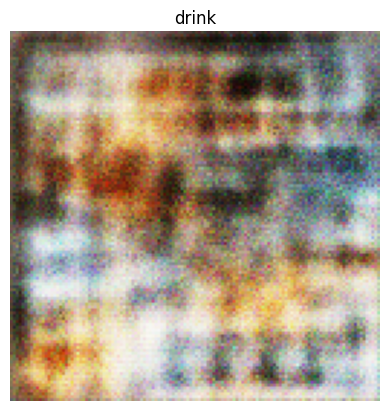

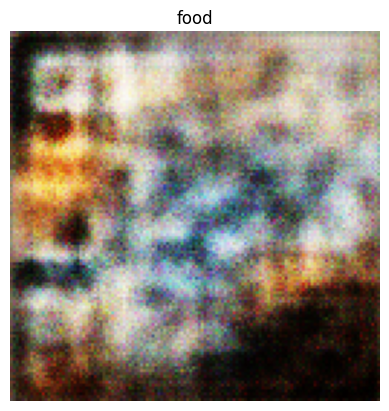

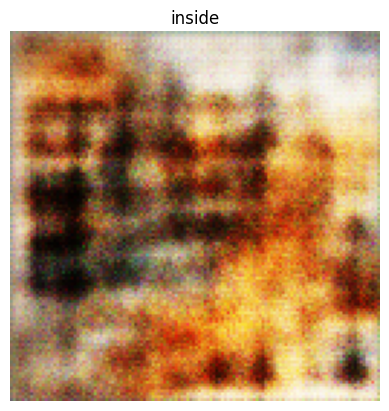

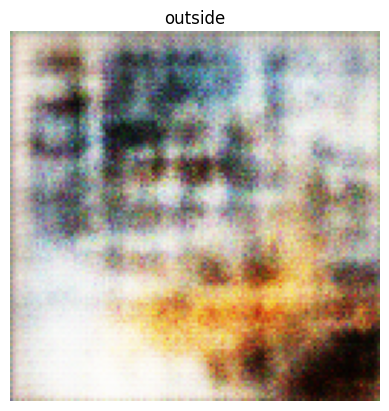

In [13]:
generate_samples()

# Iteration 2

## Generator

In [16]:
def build_generator():
    label_input = layers.Input(shape=(num_classes,))
    noise_input = layers.Input(shape=(NOISE_DIM,))
    x = layers.Concatenate()([noise_input, label_input])

    x = layers.Dense((IMG_SIZE // 16) * (IMG_SIZE // 16) * 512, use_bias=False)(x)
    x = layers.Reshape((IMG_SIZE // 16, IMG_SIZE // 16, 512))(x)

    x = layers.Conv2DTranspose(256, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(IMG_CHANNELS, 5, strides=2, padding='same', use_bias=False, activation='tanh')(x)

    return tf.keras.Model([noise_input, label_input], x, name='Generator')


## Discriminator

In [17]:
def build_critic():
    image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS))
    label_input = layers.Input(shape=(num_classes,))

    label_map = layers.Dense(IMG_SIZE * IMG_SIZE)(label_input)
    label_map = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(label_map)
    x = layers.Concatenate()([image_input, label_map])

    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, 5, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1)(x)

    return tf.keras.Model([image_input, label_input], x, name='Critic')


## Gradient Penalty

In [18]:
def gradient_penalty(critic, real, fake, labels):
    alpha = tf.random.uniform([real.shape[0], 1, 1, 1], 0., 1.)
    interpolated = alpha * real + (1 - alpha) * fake
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        validity = critic([interpolated, labels])
    grads = tape.gradient(validity, [interpolated])[0]
    gp = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
    return tf.reduce_mean((gp - 1.0) ** 2)


## Training Setup

In [ ]:
tf.keras.backend.clear_session()
generator = build_generator()
critic = build_critic()

g_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)
c_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)

train_gen = data_generator(df, BATCH_SIZE)
CRITIC_UPDATES = 5
LAMBDA_GP = 10

@tf.function
def train_step(real_imgs, labels):
    noise = tf.random.normal([real_imgs.shape[0], NOISE_DIM])
    
    for _ in range(CRITIC_UPDATES):
        with tf.GradientTape() as c_tape:
            fake_imgs = generator([noise, labels], training=True)
            real_validity = critic([real_imgs, labels], training=True)
            fake_validity = critic([fake_imgs, labels], training=True)
            gp = gradient_penalty(critic, real_imgs, fake_imgs, labels)
            c_loss = tf.reduce_mean(fake_validity) - tf.reduce_mean(real_validity) + LAMBDA_GP * gp

        c_grads = c_tape.gradient(c_loss, critic.trainable_variables)
        c_optimizer.apply_gradients(zip(c_grads, critic.trainable_variables))

    with tf.GradientTape() as g_tape:
        fake_imgs = generator([noise, labels], training=True)
        fake_validity = critic([fake_imgs, labels], training=True)
        g_loss = -tf.reduce_mean(fake_validity)

    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))
    
    return c_loss, g_loss


## Training Loop with Early Stopping

In [ ]:
steps_per_epoch = len(df) // BATCH_SIZE

patience = 5
best_g_loss = float('inf')
counter = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    epoch_c_loss, epoch_g_loss = [], []

    for step in tqdm(range(steps_per_epoch)):
        real_imgs, labels = next(train_gen)
        c_loss, g_loss = train_step(tf.convert_to_tensor(real_imgs, dtype=tf.float32),
                                    tf.convert_to_tensor(labels, dtype=tf.float32))
        epoch_c_loss.append(c_loss)
        epoch_g_loss.append(g_loss)

    mean_g_loss = np.mean(epoch_g_loss)
    print(f"Critic Loss: {np.mean(epoch_c_loss):.4f}, Generator Loss: {mean_g_loss:.4f}")

    if mean_g_loss < best_g_loss:
        best_g_loss = mean_g_loss
        counter = 0
        print("Improved Generator loss.")
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{patience}")
        if counter >= patience:
            print("Early stopping triggered.")
            break



Epoch 1/30


100%|██████████| 187/187 [05:42<00:00,  1.83s/it]


Critic Loss: -85.7408, Generator Loss: 237.2702
Improved Generator loss.

Epoch 2/30


100%|██████████| 187/187 [05:37<00:00,  1.80s/it]


Critic Loss: -44.7018, Generator Loss: 198.4347
Improved Generator loss.

Epoch 3/30


...

Critic Loss: -29.5176, Generator Loss: -16.7707
No improvement. Patience counter: 3/5

Epoch 16/30


100%|██████████| 187/187 [05:30<00:00,  1.77s/it]


Critic Loss: -29.1968, Generator Loss: -6.8540
No improvement. Patience counter: 4/5

Epoch 17/30


100%|██████████| 187/187 [05:31<00:00,  1.77s/it]


Critic Loss: -28.6402, Generator Loss: -9.1738
No improvement. Patience counter: 5/5
Early stopping triggered.


## Evaluation

In [ ]:
num_eval = 100
noise = tf.random.normal([num_eval, NOISE_DIM])
random_classes = np.random.choice(num_classes, num_eval)
gen_labels = tf.keras.utils.to_categorical(random_classes, num_classes)
generated_imgs = generator([noise, gen_labels], training=False)
generated_imgs = (generated_imgs + 1.0) / 2.0

real_subset = df.sample(n=num_eval, random_state=42)
real_imgs = np.array([load_image(p) for p in real_subset['image_path']])
real_imgs = (real_imgs + 1.0) / 2.0

real_imgs = tf.convert_to_tensor(real_imgs, dtype=tf.float32)
generated_imgs = tf.convert_to_tensor(generated_imgs, dtype=tf.float32)

is_score = calculate_inception_score(generated_imgs)
fid_score = calculate_fid(real_imgs, generated_imgs)
print(f"\nFinal Evaluation:\nInception Score: {is_score:.4f} | FID Score: {fid_score:.4f}")



Final Evaluation:
Inception Score: 199.1066 | FID Score: 1.2151


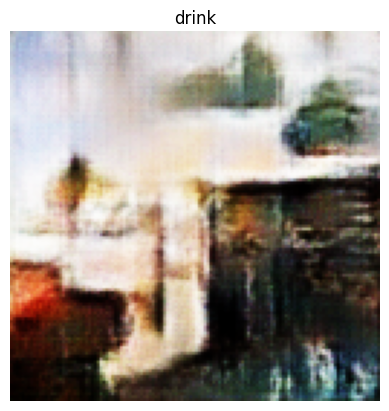

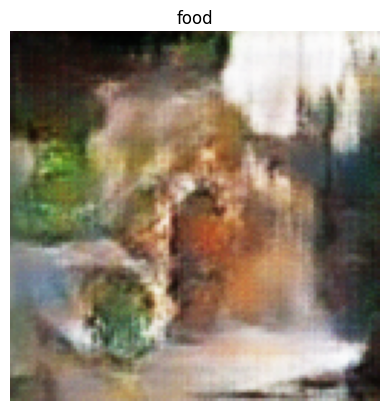

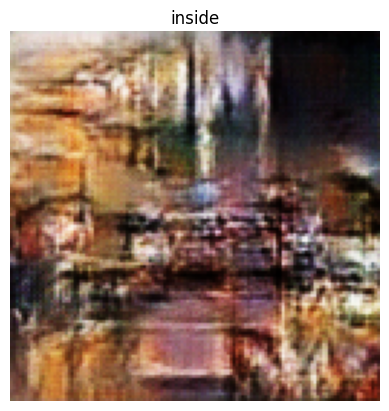

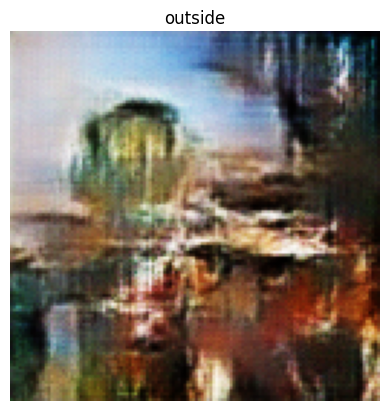

In [24]:
generate_samples()

# Iteration 3

## Initializing parameters

In [ ]:
# === Global Config ===
USE_128 = True
IMG_CHANNELS = 3
BATCH_SIZE = 64
NOISE_DIM = 100
EPOCHS = 50

C:\Users\amrut\AppData\Local\Temp\ipykernel_23108\1138548158.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label').apply(lambda x: x.sample(n=3000, random_state=42)).reset_index(drop=True)


## Generator

In [ ]:
def build_generator():
    label_input = layers.Input(shape=(num_classes,))
    noise_input = layers.Input(shape=(NOISE_DIM,))
    x = layers.Concatenate()([noise_input, label_input])

    x = layers.Dense((IMG_SIZE // 16) * (IMG_SIZE // 16) * 512, use_bias=False)(x)
    x = layers.Reshape((IMG_SIZE // 16, IMG_SIZE // 16, 512))(x)

    x = layers.Conv2DTranspose(256, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(IMG_CHANNELS, 5, strides=2, padding='same', use_bias=False, activation='tanh')(x)

    return tf.keras.Model([noise_input, label_input], x, name='Generator')


## Discriminator

In [ ]:
def build_critic():
    image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS))
    label_input = layers.Input(shape=(num_classes,))

    label_map = layers.Dense(IMG_SIZE * IMG_SIZE)(label_input)
    label_map = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(label_map)
    x = layers.Concatenate()([image_input, label_map])

    x = layers.Conv2D(64, 5, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 5, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, 5, strides=2, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1)(x)

    return tf.keras.Model([image_input, label_input], x, name='Critic')


## Gradient Penalty

In [ ]:
def gradient_penalty(critic, real, fake, labels):
    alpha = tf.random.uniform([real.shape[0], 1, 1, 1], 0., 1.)
    interpolated = alpha * real + (1 - alpha) * fake
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        validity = critic([interpolated, labels])
    grads = tape.gradient(validity, [interpolated])[0]
    gp = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
    return tf.reduce_mean((gp - 1.0) ** 2)


## Training Setup

In [ ]:
tf.keras.backend.clear_session()
generator = build_generator()
critic = build_critic()

g_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)
c_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5, beta_2=0.9)

train_gen = data_generator(df, BATCH_SIZE)
CRITIC_UPDATES = 3
LAMBDA_GP = 10

@tf.function
def train_step(real_imgs, labels):
    noise = tf.random.normal([real_imgs.shape[0], NOISE_DIM])
    
    for _ in range(CRITIC_UPDATES):
        with tf.GradientTape() as c_tape:
            fake_imgs = generator([noise, labels], training=True)
            real_validity = critic([real_imgs, labels], training=True)
            fake_validity = critic([fake_imgs, labels], training=True)
            gp = gradient_penalty(critic, real_imgs, fake_imgs, labels)
            c_loss = tf.reduce_mean(fake_validity) - tf.reduce_mean(real_validity) + LAMBDA_GP * gp

        c_grads = c_tape.gradient(c_loss, critic.trainable_variables)
        c_optimizer.apply_gradients(zip(c_grads, critic.trainable_variables))

    with tf.GradientTape() as g_tape:
        fake_imgs = generator([noise, labels], training=True)
        fake_validity = critic([fake_imgs, labels], training=True)
        g_loss = -tf.reduce_mean(fake_validity)

    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))
    
    return c_loss, g_loss


## Training Loop with Early Stopping

In [ ]:
steps_per_epoch = len(df) // BATCH_SIZE

patience = 7
best_g_loss = float('inf')
counter = 0
best_generator_path = "best_generator_model.h5"  # File to save best model

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    epoch_c_loss, epoch_g_loss = [], []

    for step in tqdm(range(steps_per_epoch)):
        real_imgs, labels = next(train_gen)
        c_loss, g_loss = train_step(tf.convert_to_tensor(real_imgs, dtype=tf.float32),
                                    tf.convert_to_tensor(labels, dtype=tf.float32))
        epoch_c_loss.append(c_loss)
        epoch_g_loss.append(g_loss)

    mean_g_loss = np.mean(epoch_g_loss)
    mean_c_loss = np.mean(epoch_c_loss)
    print(f"Critic Loss: {mean_c_loss:.4f}, Generator Loss: {mean_g_loss:.4f}")

    if mean_g_loss < best_g_loss:
        best_g_loss = mean_g_loss
        counter = 0
        print("Improved Generator loss. Saving generator...")
        generator.save(best_generator_path)
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{patience}")
        if counter >= patience:
            print("Early stopping triggered.")
            break



Epoch 1/50


100%|██████████| 187/187 [03:31<00:00,  1.13s/it]


Critic Loss: -61.6952, Generator Loss: 127.6104
Improved Generator loss. Saving generator...

Epoch 2/50


100%|██████████| 187/187 [03:29<00:00,  1.12s/it]


Critic Loss: -32.0649, Generator Loss: 64.0550
Improved Generator loss. Saving generator...

Epoch 3/50


...

Critic Loss: -21.0966, Generator Loss: -35.5431
No improvement. Patience counter: 5/7

Epoch 13/50


100%|██████████| 187/187 [03:30<00:00,  1.12s/it]


Critic Loss: -20.7068, Generator Loss: -39.8528
No improvement. Patience counter: 6/7

Epoch 14/50


100%|██████████| 187/187 [03:30<00:00,  1.13s/it]


Critic Loss: -21.0937, Generator Loss: -41.6041
No improvement. Patience counter: 7/7
Early stopping triggered.


In [ ]:
# === Evaluation after training finishes ===
num_eval = 500
noise = tf.random.normal([num_eval, NOISE_DIM])
random_classes = np.random.choice(num_classes, num_eval)
gen_labels = tf.keras.utils.to_categorical(random_classes, num_classes)
generated_imgs = generator([noise, gen_labels], training=False)
generated_imgs = (generated_imgs + 1.0) / 2.0

real_subset = df.sample(n=num_eval, random_state=42)
real_imgs = np.array([load_image(p) for p in real_subset['image_path']])
real_imgs = (real_imgs + 1.0) / 2.0

real_imgs = tf.convert_to_tensor(real_imgs, dtype=tf.float32)
generated_imgs = tf.convert_to_tensor(generated_imgs, dtype=tf.float32)

is_score = calculate_inception_score(generated_imgs)
fid_score = calculate_fid(real_imgs, generated_imgs)
print(f"\nFinal Evaluation:\nInception Score: {is_score:.4f} | FID Score: {fid_score:.4f}")


## Generate One Image Per Label

In [ ]:
def generate_samples():
    noise = tf.random.normal([num_classes, NOISE_DIM])
    label_vecs = tf.eye(num_classes)
    generated_images = generator([noise, label_vecs], training=False)

    for i in range(num_classes):
        img = (generated_images[i] + 1) * 127.5
        img = tf.cast(img, tf.uint8).numpy()
        plt.imshow(img)
        plt.axis("off")
        plt.title(label_encoder.inverse_transform([i])[0])
        plt.show()

# Call after training:
# generate_samples()


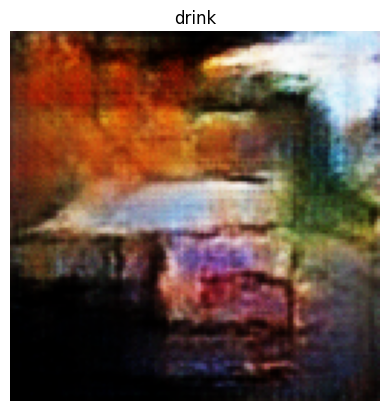

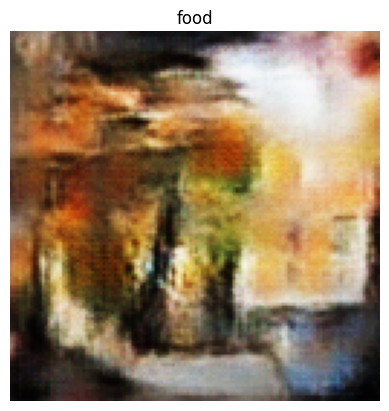

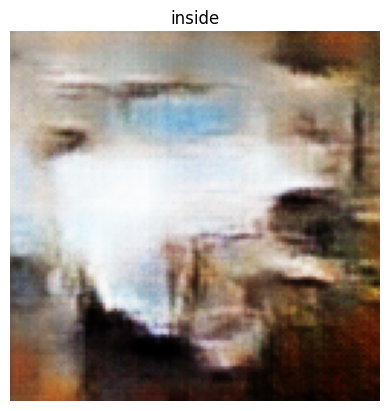

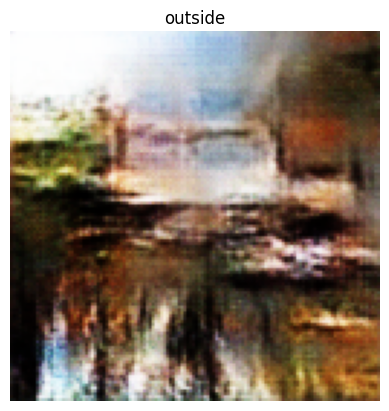

In [ ]:
generate_samples()